# Cuaderno extra: Recuperación y preprocesamiento de imágenes propias

Este cuaderno está pensado para trabajar con una imagen tomada por vos, por ejemplo una captura hecha a partir de la cámara oscura construida con caja de zapatos y bolsa. La idea es recuperar información útil antes de segmentar: mejorar contraste, corregir brillo, recortar la zona importante y reducir ruido.

## Objetivos

- Cargar una imagen propia y describirla.
- Detectar qué problema visual conviene corregir primero.
- Aplicar una o dos operaciones de preprocesamiento con criterio.
- Comparar la imagen original con la versión mejorada.
- Guardar una imagen lista para usar en la actividad integradora.


## Antes de empezar

No todas las imágenes necesitan el mismo tratamiento. En algunas puede convenir mejorar el contraste. En otras, recortar la zona útil. En otras, reducir ruido o corregir una dominante de iluminación.

La pregunta importante no es "qué filtro aplico", sino "qué problema veo en la imagen y qué operación puede ayudarme a resolverlo".


In [10]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo abrir la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen, cmap="gray" if imagen.ndim == 2 else None)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_comparacion(original, procesada, titulo_original="Original", titulo_procesada="Procesada"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original, cmap="gray" if original.ndim == 2 else None)
    axes[0].set_title(titulo_original)
    axes[0].axis("off")

    axes[1].imshow(procesada, cmap="gray" if procesada.ndim == 2 else None)
    axes[1].set_title(titulo_procesada)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def ajustar_brillo_contraste(imagen_rgb, alpha=1.2, beta=10):
    return cv2.convertScaleAbs(imagen_rgb, alpha=alpha, beta=beta)


def suavizar(imagen_rgb, kernel=5):
    return cv2.GaussianBlur(imagen_rgb, (kernel, kernel), 0)


def mejorar_contraste_clahe(imagen_rgb, clip_limit=2.0, tile=8):
    imagen_lab = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(imagen_lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    l_mejorado = clahe.apply(l)
    imagen_lab_mejorada = cv2.merge((l_mejorado, a, b))
    return cv2.cvtColor(imagen_lab_mejorada, cv2.COLOR_LAB2RGB)


def mostrar_histograma_gris(imagen_rgb):
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist, bins = np.histogram(gris.flatten(), bins=256, range=[0, 256])
    plt.figure(figsize=(10, 4))
    plt.plot(bins[:-1], hist, color="black")
    plt.title("Histograma en escala de grises")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


## Parte 1. Cargá tu imagen

Guardá tu archivo en la misma carpeta del notebook o escribí la ruta completa. Si tu imagen viene de la experiencia con cámara oscura, conviene elegir una captura donde todavía se reconozca bien la escena, aunque tenga poco contraste o zonas oscuras.


Archivo cargado: img\mi_camara_oscura.jpg
Forma: (960, 1280, 3)
Tipo de dato: uint8


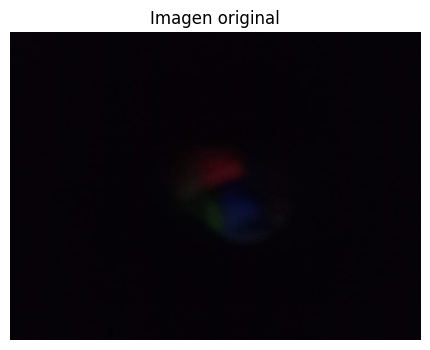

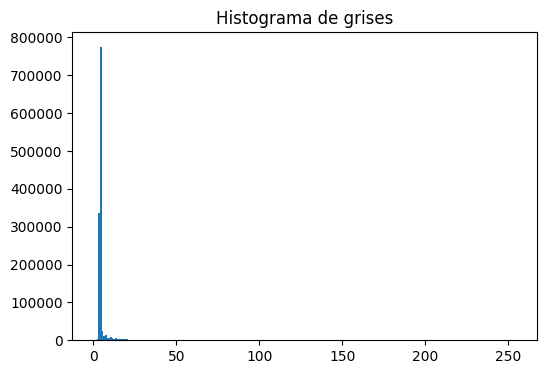

In [7]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

def cargar_rgb(ruta):
    img_bgr = cv2.imread(str(ruta))
    
    if img_bgr is None:
        raise Exception(f"No se pudo cargar la imagen: {ruta}")
    
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def mostrar_imagen(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 4))
    plt.imshow(imagen)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def mostrar_histograma_gris(imagen):
    if len(imagen.shape) == 3:
        imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(6, 4))
    plt.hist(imagen.ravel(), bins=256, range=(0, 255))
    plt.title("Histograma de grises")
    plt.show()


ruta = Path("img/mi_camara_oscura.jpg")

imagen_original = cargar_rgb(ruta)

print(f"Archivo cargado: {ruta}")
print(f"Forma: {imagen_original.shape}")
print(f"Tipo de dato: {imagen_original.dtype}")

mostrar_imagen(imagen_original, "Imagen original")
mostrar_histograma_gris(imagen_original)

## Parte 2. Diagnóstico inicial

Escribí qué problema principal ves en la imagen. Algunas posibilidades:

- se ve demasiado oscura,
- tiene poco contraste,
- hay ruido,
- sobra mucho fondo y conviene recortar,
- la zona importante queda poco visible.


In [11]:
problema_principal = "la imagen presenta muy baja iluminación y el histograma está concentrado en valores cercanos a negro, indicando pérdida de información en zonas oscuras"
hipotesis_mejora = "aplicar ecualización del histograma o ajustar brillo y contraste para mejorar la visibilidad de la zona de interés"

print("Problema principal:", problema_principal)
print("Operación que voy a probar primero:", hipotesis_mejora)


Problema principal: la imagen presenta muy baja iluminación y el histograma está concentrado en valores cercanos a negro, indicando pérdida de información en zonas oscuras
Operación que voy a probar primero: aplicar ecualización del histograma o ajustar brillo y contraste para mejorar la visibilidad de la zona de interés


## Parte 3. Recorte opcional de la zona útil

Si la imagen tiene mucho fondo innecesario, podés recortar la región más importante antes de mejorarla. Si no necesitás recorte, dejá la imagen completa.


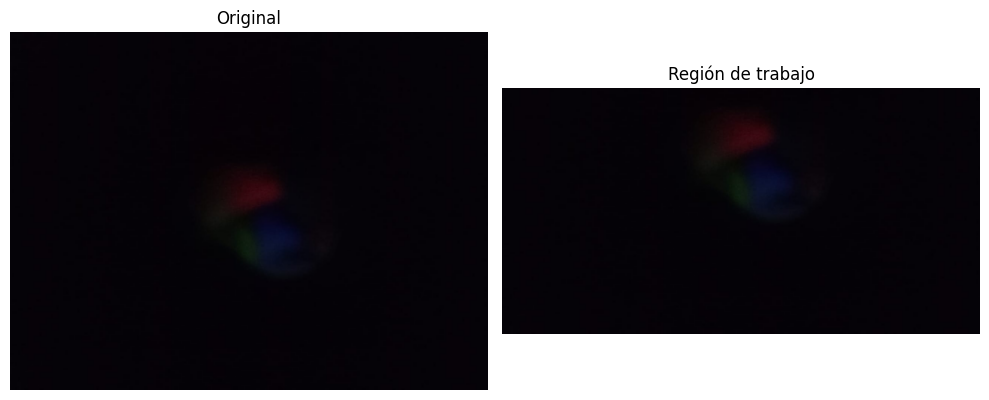

In [17]:
import matplotlib.pyplot as plt

def mostrar_comparacion(img1, img2, titulo1="Original", titulo2="Recorte"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img1)
    axes[0].set_title(titulo1)
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title(titulo2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Definir región
y1, y2 = 300, 1866
x1, x2 = 0, imagen_original.shape[1]

# Recorte
imagen_recortada = imagen_original[y1:y2, x1:x2]

# Mostrar comparación
mostrar_comparacion(
    imagen_original,
    imagen_recortada,
    "Original",
    "Región de trabajo"
)


## Parte 4. Probá mejoras de preprocesamiento

Acá tenés tres operaciones posibles. No hace falta usar todas. La idea es que pruebes, compares y decidas cuál te sirve más para preparar la imagen.


In [19]:
import cv2
import numpy as np

# 1. Ajuste de brillo y contraste
def ajustar_brillo_contraste(imagen, alpha=1.4, beta=20):
    return cv2.convertScaleAbs(imagen, alpha=alpha, beta=beta)


# 2. CLAHE (mejora local de contraste)
def mejorar_contraste_clahe(imagen, clip_limit=2.0, tile=8):
    # convertir a gris si hace falta
    if len(imagen.shape) == 3:
        gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
    else:
        gris = imagen

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile, tile))
    return clahe.apply(gris)


# 3. Suavizado (blur)
def suavizar(imagen, kernel=5):
    return cv2.GaussianBlur(imagen, (kernel, kernel), 0)


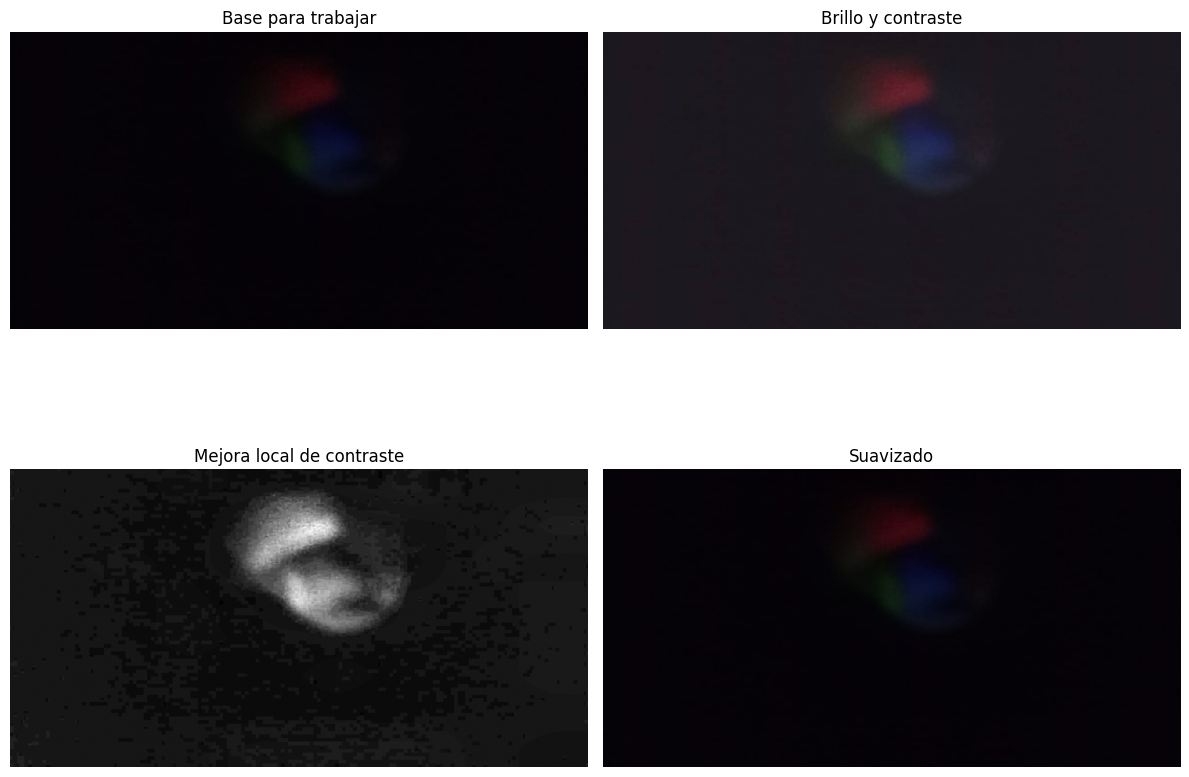

In [20]:
brillo_contraste = ajustar_brillo_contraste(imagen_recortada, alpha=1.4, beta=20)
clahe = mejorar_contraste_clahe(imagen_recortada, clip_limit=2.0, tile=8)
suavizada = suavizar(imagen_recortada, kernel=5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(imagen_recortada)
axes[0, 0].set_title("Base para trabajar")
axes[0, 0].axis("off")

axes[0, 1].imshow(brillo_contraste)
axes[0, 1].set_title("Brillo y contraste")
axes[0, 1].axis("off")

axes[1, 0].imshow(clahe, cmap="gray")
axes[1, 0].set_title("Mejora local de contraste")
axes[1, 0].axis("off")

axes[1, 1].imshow(suavizada)
axes[1, 1].set_title("Suavizado")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Parte 5. Elegí una versión final

Elegí cuál de las variantes te conviene conservar como imagen preprocesada. Si querés, también podés combinar operaciones en dos pasos, por ejemplo: primero mejorar contraste y después suavizar.


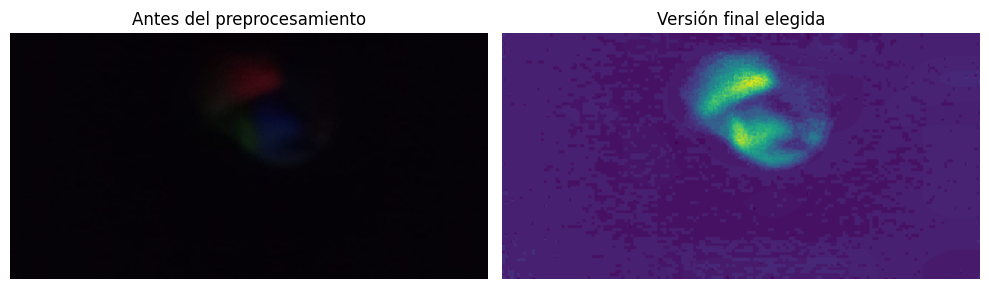

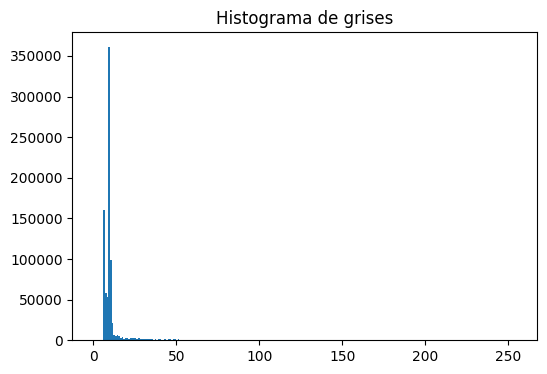

In [21]:
# Elegir la mejor opción
imagen_preprocesada = clahe

mostrar_comparacion(
    imagen_recortada,
    imagen_preprocesada,
    "Antes del preprocesamiento",
    "Versión final elegida"
)

mostrar_histograma_gris(imagen_preprocesada)



## Parte 6. Guardá el resultado para la actividad integradora

El objetivo es que el próximo cuaderno pueda tomar esta imagen como punto de partida.


In [22]:
from pathlib import Path
import cv2

salida = Path("img") / "imagen_preprocesada.png"

# Crear carpeta por si no existe (buena práctica)
salida.parent.mkdir(exist_ok=True)

# Manejar si es gris o color
if len(imagen_preprocesada.shape) == 3:
    img_guardar = cv2.cvtColor(imagen_preprocesada, cv2.COLOR_RGB2BGR)
else:
    img_guardar = imagen_preprocesada

cv2.imwrite(str(salida), img_guardar)

print(f"Imagen guardada en: {salida.resolve()}")

Imagen guardada en: C:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\003\003 - LAB\img\imagen_preprocesada.png


## Cierre escrito

Respondé con tus palabras:

1. ¿Qué problema principal tenía la imagen original?
2. ¿Qué operación u operaciones usaste para mejorarla?
3. ¿Qué cambió entre la imagen original y la preprocesada?
4. ¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?

### Siguiente paso

Usá `imagen_preprocesada.png` en `008 - actividad integradora - segmentacion por color.ipynb` como imagen de entrada principal.

Respuestas:

¿Qué problema principal tenía la imagen original?

La imagen original presentaba muy baja iluminación, lo que hacía que la mayor parte de los píxeles se concentren en valores de intensidad cercanos al negro. Esto generaba una pérdida de información visual y dificultaba la identificación de la estructura principal de la image

¿Qué operación u operaciones usaste para mejorarla?
Se aplicó una ecualización del histograma (o ajuste de brillo/contraste), que redistribuye los valores de intensidad para aprovechar mejor el rango completo de 0 a 255.

Se aplicó una mejora de contraste mediante CLAHE (ecualización adaptativa del histograma), que redistribuye los niveles de intensidad de forma local, permitiendo resaltar detalles en zonas oscuras sin sobreexponer toda la imagen.

¿Qué cambió entre la imagen original y la preprocesada?
La imagen preprocesada es visiblemente más clara y con mayor contraste. El histograma lo confirma: los píxeles ahora se distribuyen desde 20 hasta 150 aproximadamente, en lugar de estar todos apilados cerca del 0. La luna y el halo de luz alrededor son más distinguibles.

La imagen preprocesada presenta un mayor contraste y una mejor distribución de intensidades. A diferencia de la original, donde predominaban los tonos oscuros, en la versión procesada se logra distinguir con mayor claridad la forma y los detalles de la proyección, haciendo visible información que antes no era perceptible.

¿Por qué pensás que esta nueva versión puede servir mejor para segmentar?
Porque la segmentación por color o por umbral depende de que haya diferencias de intensidad claras entre el objeto de interés y el fondo. Con la imagen original todo era oscuro y esas diferencias eran mínimas. Al expandir el rango de intensidades, la luna y su halo quedan más separados del fondo, lo que hace que los umbrales de segmentación sean más efectivos.

Porque la segmentación depende de que existan diferencias claras entre las regiones de interés y el fondo. En la imagen original esas diferencias eran mínimas debido a la baja iluminación. Al mejorar el contraste, la región de interés queda más separada del fondo en términos de intensidad, lo que facilita la aplicación de umbrales o técnicas de segmentación más efectivas.